In [1]:
# --- Imports
import os
import numpy as np
import matplotlib.pyplot as plt

import rasterio
from rasterio.features import shapes
from rasterio.plot import plotting_extent
import geopandas as gpd

from shapely.geometry import shape, Polygon, MultiPolygon, LineString
from shapely.ops import unary_union

from skimage.morphology import binary_closing, disk, skeletonize
from skimage.measure import label, regionprops

from matplotlib.colors import LinearSegmentedColormap

plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
# --- User settings
tif_path = "MBS_data/TG20250726_straight1.tiff"
out_png = "outputs/mbs_swath_centerline.png"

cmap_blue_yellow = LinearSegmentedColormap.from_list("blue_yellow", [(0.0, "navy"), (1.0, "gold")])

# morphology
closing_radius_px = 3
min_region_area_px = 500

# skeleton/centerline smoothing
smooth_window = 30  # odd number recommended; 0 = no smoothing

os.makedirs(os.path.dirname(out_png), exist_ok=True)

In [3]:
# --- Load raster & build valid mask
with rasterio.open(tif_path) as ds:
    band1 = ds.read(1, masked=True)
    transform = ds.transform
    crs = ds.crs
    extent = plotting_extent(ds)

data = np.array(band1.filled(np.nan), dtype=float)
valid = (~band1.mask).astype(bool)
if np.issubdtype(band1.dtype, np.floating):
    valid &= np.isfinite(data)

In [4]:
# --- Clean mask: close gaps, remove small islands, fill holes
def clean_mask(mask, closing_radius=3, min_area=500):
    m = mask.copy()
    if closing_radius > 0:
        m = binary_closing(m, disk(closing_radius))
    lab = label(m)
    props = regionprops(lab)
    keep_labels = {p.label for p in props if p.area >= min_area}
    m = np.isin(lab, list(keep_labels))
    inv = ~m
    lab_bg = label(inv)
    border = np.zeros_like(inv, dtype=bool)
    border[0,:] = True; border[-1,:] = True; border[:,0] = True; border[:,-1] = True
    border_labels = set(np.unique(lab_bg[border]))
    inv_filtered = np.isin(lab_bg, list(border_labels))
    m = ~inv_filtered
    return m

clean = clean_mask(valid, closing_radius=closing_radius_px, min_area=min_region_area_px)

In [5]:
# --- Polygonize and compute outer boundary (envelope)
polys = [shape(geom) for geom, val in shapes(clean.astype(np.uint8), mask=clean, transform=transform) if val == 1]
if not polys:
    raise RuntimeError('No swath region found; tweak min_region_area_px or closing_radius_px.')

swath_union = unary_union(polys)
if isinstance(swath_union, Polygon):
    swath_union = MultiPolygon([swath_union])

outer_lines = []
for g in swath_union.geoms:
    outer_lines.append(LineString(g.exterior.coords))
outer_outline = unary_union(outer_lines)

bxmin, bymin, bxmax, bymax = swath_union.bounds
pad_x = 0.05 * (bxmax - bxmin + 1e-9)
pad_y = 0.05 * (bymax - bymin + 1e-9)
xlim = (bxmin - pad_x, bxmax + pad_x)
ylim = (bymin - pad_y, bymax + pad_y)

In [6]:
# --- Skeletonize to get centerline pixels
skeleton = skeletonize(clean)  # 1-pixel wide skeleton

In [7]:
# --- Build 8-connected graph on skeleton, find longest path via double BFS
from collections import deque

H, W = skeleton.shape
ys, xs = np.nonzero(skeleton)
indices = list(zip(ys, xs))
idx_map = {(y,x): i for i,(y,x) in enumerate(indices)}

neighbors8 = [(-1,-1), (-1,0), (-1,1), (0,-1), (0,1), (1,-1), (1,0), (1,1)]

adj = [[] for _ in range(len(indices))]
deg = np.zeros(len(indices), dtype=int)
for i,(y,x) in enumerate(indices):
    for dy,dx in neighbors8:
        ny, nx = y+dy, x+dx
        if (ny, nx) in idx_map:
            j = idx_map[(ny,nx)]
            adj[i].append(j)
    deg[i] = len(adj[i])

def bfs_far(start):
    n = len(indices)
    dist = [-1]*n
    prev = [-1]*n
    q = deque([start]); dist[start]=0
    last = start
    while q:
        u = q.popleft()
        last = u
        for v in adj[u]:
            if dist[v] == -1:
                dist[v] = dist[u] + 1
                prev[v] = u
                q.append(v)
    return last, prev, dist

if len(indices) < 2:
    raise RuntimeError('Skeleton too small to extract a path.')

endpoints = [i for i,d in enumerate(deg) if d == 1]
start0 = endpoints[0] if len(endpoints) >= 1 else 0
a, prev_a, _ = bfs_far(start0)
b, prev_b, _ = bfs_far(a)

# backtrack a->b
path_ids = []
cur = b
visited = set()
while cur != -1 and cur not in visited:
    path_ids.append(cur)
    visited.add(cur)
    if cur == a:
        break
    cur = prev_b[cur]
path_ids = path_ids[::-1]

if len(path_ids) < 10 and len(endpoints) >= 2:
    # fallback: try farthest among endpoints
    best_len = -1
    best_prev = None
    best_v = None
    for u in endpoints[: min(50, len(endpoints))]:
        v, prev_u, dist = bfs_far(u)
        if dist[v] > best_len:
            best_len = dist[v]
            best_prev = prev_u
            best_v = v
    # backtrack
    path_ids = []
    cur = best_v
    visited = set()
    while cur != -1 and cur not in visited:
        path_ids.append(cur)
        visited.add(cur)
        if best_prev[cur] == -1:
            break
        cur = best_prev[cur]
    path_ids = path_ids[::-1]

In [8]:
# --- Convert path pixels to map coordinates and smooth
rows = np.array([indices[i][0] for i in path_ids], dtype=float)
cols = np.array([indices[i][1] for i in path_ids], dtype=float)
Xs, Ys = rasterio.transform.xy(transform, rows, cols, offset='center')
Xs = np.asarray(Xs); Ys = np.asarray(Ys)

def moving_average(a, w):
    if w is None or w <= 1:
        return a
    pad = w//2
    a_pad = np.pad(a, (pad,pad), mode='edge')
    kernel = np.ones(w) / w
    return np.convolve(a_pad, kernel, mode='same')[pad:-pad]

if smooth_window and smooth_window > 1 and (smooth_window % 2 == 1):
    Xs_s = moving_average(Xs, smooth_window)
    Ys_s = moving_average(Ys, smooth_window)
else:
    Xs_s, Ys_s = Xs, Ys

Saved centerline as shapefile: outputs/mbs_swath_centerline_centerline.shp


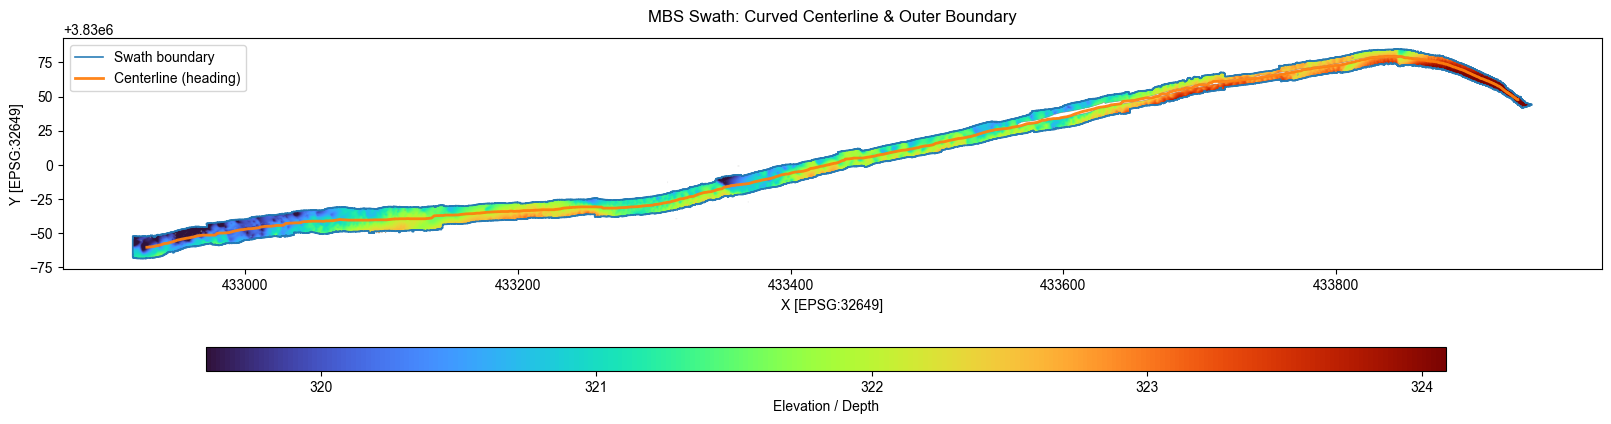

Saved: outputs/mbs_swath_centerline.png


In [9]:
# --- Plot & Save (updated)
fig, ax = plt.subplots(figsize=(16, 8), constrained_layout=True)

finite_vals = data[np.isfinite(data)]
if finite_vals.size < 10:
    raise RuntimeError('Too few finite values to display.')
vmin, vmax = np.percentile(finite_vals, [2, 98])

cmap = plt.get_cmap('turbo')

im = ax.imshow(
    data, cmap=cmap, vmin=vmin, vmax=vmax,
    origin='upper', extent=extent
)
im.set_alpha(np.where(np.isfinite(data), 1.0, 0.0))

def plot_outline(geom, ax, **kw):
    if geom.geom_type == 'MultiLineString':
        for g in geom.geoms:
            x, y = g.xy
            ax.plot(x, y, **kw)
    else:
        x, y = geom.xy
        ax.plot(x, y, **kw)

plot_outline(outer_outline, ax, linewidth=1.2, alpha=0.95, label='Swath boundary')

n = len(Xs_s)
cut = max(1, int(0.01 * n))
if 2 * cut < n:
    Xp = Xs_s[cut:-cut]
    Yp = Ys_s[cut:-cut]
else:
    Xp, Yp = Xs_s, Ys_s
centerline_geom = LineString(list(zip(Xp, Yp)))
gdf_centerline = gpd.GeoDataFrame(
    geometry=[centerline_geom],
    crs=crs.to_string() if hasattr(crs, 'to_string') else crs
)
shp_path = out_png.replace('.png', '_centerline.shp')
try:
    gdf_centerline.to_file(shp_path, driver='ESRI Shapefile', encoding='utf-8')
    print(f'Saved centerline as shapefile: {shp_path}')
except Exception as e:
    print(f'Failed to save shapefile: {e}')



ax.plot(Xp, Yp, '-', linewidth=2.0, alpha=0.95, label='Centerline (heading)')

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

crs_txt = crs.to_string() if crs else 'map units'
ax.set_title('MBS Swath: Curved Centerline & Outer Boundary', pad=12)
ax.set_xlabel(f'X [{crs_txt}]')
ax.set_ylabel(f'Y [{crs_txt}]')

bbox = ax.get_position()  # [x0, y0, width, height] in figure coords
cax = fig.add_axes([bbox.x0, bbox.y0 - 0.15, bbox.width, 0.03])  # 放在轴下方
cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label('Elevation / Depth')

ax.legend(loc='best', frameon=True)

fig.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved: {out_png}')


In [10]:
# === Sand-wave orientation along track via sliding-window 2D-DFT (Spectrum Second-Moment) ===
# Robust orientation via spectral structure tensor + SOFT axis-notch + ring normalization
# + adaptive cross-window shrinking when valid fraction is low.
#

import os, json, math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from matplotlib.collections import LineCollection

# ---------------- Parameters ----------------
step_analyze_m = 2.0
step_visual_m  = 5.0

Lt, Ln = 60.0, 30.0      # 沿/法向窗尺寸（m）
nt, nn = 128, 64         # 窗内采样点数（沿/法向）

# 目标波长范围（m）→ 频率范围（cycles/m）
lam_min, lam_max = 1.0, 80.0
fmin, fmax = 1.0/lam_max, 1.0/lam_min

# 频谱轴向凹口（抑制 kx≈0 或 ky≈0 伪影）
k_notch = 0.02           # cycles/m，按数据分辨率与窗大小调（这里将作为软凹口的尺度）

# 有效性与质量阈值
min_valid_frac = 0.40    # 窗内有效像素比例
qsharp_min     = 2.0     # 质量阈值（λmax/λmin 比值）

# 沿程圆统计平滑窗口（m）
smooth_len_m   = 12.0    # 设 0 关闭

# 输出
os.makedirs("outputs", exist_ok=True)
out_geojson = "outputs/mbs_flowdir_centerline_epsg32649.geojson"  # 仅中心线 + 属性数组
out_map_png = "outputs/mbs_map_centerline_segments.png"
out_qc_png  = "outputs/mbs_flowdir_qc.png"

# ---------------- Helpers ----------------
def polyline_arclength(xs, ys):
    d = np.hypot(np.diff(xs), np.diff(ys))
    return np.concatenate([[0.0], np.cumsum(d)])

def resample_polyline(xs, ys, step):
    s = polyline_arclength(xs, ys)
    if s[-1] == 0: return xs.copy(), ys.copy(), s
    s_new = np.arange(0.0, s[-1] + 1e-9, step)
    return np.interp(s_new, s, xs), np.interp(s_new, s, ys), s_new

def tangent_normals(xs, ys):
    dx, dy = np.gradient(xs), np.gradient(ys)
    L = np.hypot(dx, dy) + 1e-12
    tx, ty = dx/L, dy/L
    nx, ny = -ty, tx
    return tx, ty, nx, ny

def inv_affine_xy_to_rc(transform, x, y):
    Ainv = ~transform
    c, r = Ainv * (x, y)
    return r, c

def make_local_grid(cx, cy, tx, ty, nx, ny, Lt_eff, Ln_eff, nt, nn):
    T = np.linspace(-Lt_eff/2, Lt_eff/2, nt)
    N = np.linspace(-Ln_eff/2, Ln_eff/2, nn)
    TT, NN = np.meshgrid(T, N, indexing="xy")
    X = cx + TT*tx + NN*nx
    Y = cy + TT*ty + NN*ny
    return X, Y

def sample_raster(Z, transform, X, Y):
    r, c = inv_affine_xy_to_rc(transform, X, Y)
    return map_coordinates(Z, [r, c], order=1, mode="nearest")

def detrend_plane(Z, X, Y):
    m = np.isfinite(Z)
    if m.sum() < 10: return Z, 0.0
    x, y, z = X[m].ravel(), Y[m].ravel(), Z[m].ravel()
    A = np.c_[x, y, np.ones_like(x)]
    coeff, *_ = np.linalg.lstsq(A, z, rcond=None)
    Zfit = np.full_like(Z, np.nan, dtype=float)
    Zfit[m] = coeff[0]*X[m] + coeff[1]*Y[m] + coeff[2]
    return Z - Zfit, m.mean()

def hann2(nn, nt):  # 2D Hann window
    return np.outer(np.hanning(nn), np.hanning(nt))

def circ_smooth_series(angles_deg, s_coords, win_len_m):
    if win_len_m <= 0 or len(angles_deg) < 3: return angles_deg.copy()
    out = angles_deg.copy(); half = 0.5*win_len_m
    for i, si in enumerate(s_coords):
        mask = (s_coords >= si-half) & (s_coords <= si+half) & np.isfinite(angles_deg)
        if mask.sum() >= 3:
            ang2 = np.radians(angles_deg[mask])*2.0
            C, S = np.cos(ang2).mean(), np.sin(ang2).mean()
            out[i] = (np.degrees(np.arctan2(S, C))/2.0) % 180.0
    return out

# ---------------- Prepare inputs ----------------
data = data.astype(float)
Xs_in, Ys_in = np.asarray(Xs_s), np.asarray(Ys_s)
X_an, Y_an, S_an = resample_polyline(Xs_in, Ys_in, step_analyze_m)
X_5m, Y_5m, S_5m = resample_polyline(Xs_in, Ys_in, step_visual_m)
tx, ty, nx, ny = tangent_normals(X_an, Y_an)
win2 = hann2(nn, nt)

# ---------------- Main loop (structure tensor in k-space, soft-notch + adaptive shrink) ----------------
theta_flow = np.full_like(S_an, np.nan, dtype=float)  # 0..180°
quality    = np.full_like(S_an, np.nan, dtype=float)  # λmax/λmin

# 自适应缩窗参数（不改你给定的 Lt/Ln，只在局部生效）
max_shrink_trials = 3
shrink_factor     = 0.75  # 每次把 Ln_eff *= 0.75；若仍不够可再试

for i in range(len(S_an)):
    success = False
    Lt_eff, Ln_eff = Lt, Ln  # 每个位置从原始窗开始
    for trial in range(max_shrink_trials+1):
        # 采样局地网格
        Xloc, Yloc = make_local_grid(X_an[i], Y_an[i], tx[i], ty[i], nx[i], ny[i], Lt_eff, Ln_eff, nt, nn)
        Zloc = sample_raster(data, transform, Xloc, Yloc)
        vf   = np.isfinite(Zloc).mean()

        Zd, vf2 = detrend_plane(Zloc, Xloc, Yloc)
        if np.isfinite(vf) and np.isfinite(vf2) and (vf >= min_valid_frac) and (vf2 >= min_valid_frac):
            success = True
        else:
            if trial < max_shrink_trials:
                # 仅缩横向窗（更适合边缘/窄槽）
                Ln_eff *= shrink_factor
                continue
            else:
                break

        # --- 频域权重（按当前有效窗尺寸计算），软凹口 + 环归一 ---
        dt_eff = Lt_eff / (nt - 1)
        dn_eff = Ln_eff / (nn - 1)
        fx = np.fft.fftfreq(nt, d=dt_eff)
        fy = np.fft.fftfreq(nn, d=dn_eff)
        FX, FY = np.meshgrid(fx, fy, indexing="xy")
        R = np.hypot(FX, FY)

        # 带通
        band_mask = (R >= fmin) & (R <= fmax)

        # 软凹口（不置零，只是抑制轴向）
        k0 = max(1e-6, k_notch)
        w_notch = (1.0 - np.exp(-(np.abs(FX)/k0)**2)) * (1.0 - np.exp(-(np.abs(FY)/k0)**2))

        # 环归一：对每个半径环做 1/N_ring 归一
        nrings = 24
        bins = np.linspace(fmin, fmax, nrings+1)
        ring_idx = np.digitize(R, bins) - 1  # 0..nrings-1
        ring_counts = np.bincount(ring_idx[band_mask], minlength=nrings).astype(float)
        ring_counts[ring_counts == 0] = np.inf
        ring_weight = np.zeros_like(R, dtype=float)
        for k in range(nrings):
            ring_weight[(ring_idx == k) & band_mask] = 1.0 / ring_counts[k]

        # 填 NaN、乘窗并做 FFT
        Zm = np.where(np.isfinite(Zd), Zd, np.nanmean(Zd))
        Zw = Zm * win2
        F  = np.fft.fft2(Zw)
        P  = np.fft.fftshift(np.abs(F)**2)

        # 综合权重
        W = P * ring_weight * w_notch * band_mask

        # 频谱二阶矩
        Mxx = np.sum(W * (FX**2))
        Mxy = np.sum(W * (FX*FY))
        Myy = np.sum(W * (FY**2))
        M   = np.array([[Mxx, Mxy],
                        [Mxy, Myy]], dtype=float)
        evals, evecs = np.linalg.eigh(M)
        if not np.all(np.isfinite(evals)):
            success = False
        else:
            i_max = np.argmax(evals)
            vx, vy = evecs[0, i_max], evecs[1, i_max]
            theta_flow[i] = (np.degrees(np.arctan2(vy, vx)) % 180.0)
            lam_min_loc = max(evals.min(), 1e-12)
            lam_max_loc = max(evals.max(), lam_min_loc)
            quality[i]  = lam_max_loc / lam_min_loc
        break  # 本 trial 成功或失败都跳出；失败将由外层判断是否继续缩窗

    if not success:
        continue  # 留作 NaN，后面邻域替代

# 低质量点用邻域高质量替代（最近邻，≤ 2*Lt）
ok = (quality >= qsharp_min) & np.isfinite(theta_flow)
if ok.any():
    bad_idx = np.where(~ok)[0]
    for i in bad_idx:
        j = np.argmin(np.abs(S_an[ok] - S_an[i]))
        if np.abs(S_an[ok][j] - S_an[i]) <= 2.0*Lt:
            theta_flow[i] = theta_flow[ok][j]
            quality[i]    = quality[ok][j]

# 沿程圆统计平滑
theta_flow_sm = circ_smooth_series(theta_flow, S_an, smooth_len_m)

# ---------------- GeoJSON（仅中心线 + 属性数组） ----------------
centerline_coords = [[float(x), float(y)] for x, y in zip(X_an, Y_an)]
props = {
    "name": "centerline_resampled",
    "step_m": float(step_analyze_m),
    "s_m": [float(s) for s in S_an],
    "theta_flow_deg_raw": [float(a) if np.isfinite(a) else None for a in theta_flow],
    "theta_flow_deg_sm": [float(a) if np.isfinite(a) else None for a in theta_flow_sm],
    "quality": [float(q) if np.isfinite(q) else None for q in quality]
}
geojson = {
    "type": "FeatureCollection",
    "name": "mbs_flowdir_centerline",
    "crs": {"type": "name", "properties": {"name": "EPSG:32649"}},  # UTM/WGS84/49N
    "features": [{
        "type": "Feature",
        "geometry": {"type": "LineString", "coordinates": centerline_coords},
        "properties": props
    }]
}
with open(out_geojson, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)
print(f"GeoJSON saved: {out_geojson}  (centerline only)")



GeoJSON saved: outputs/mbs_flowdir_centerline_epsg32649.geojson  (centerline only)


In [11]:
# === Longitudinal profile z(s) with cross-flow averaging (stop at boundary) ===
# 需求变更：横向取样不再以“遇到长缺失就停”为准，而是“碰到 swath 的 boundary 再停止”。
# 说明：
# - 使用我们之前算过的外包络边界 `outer_outline`（MultiLineString 或 LineString）。
# - 若环境里只有 `swath_union`（MultiPolygon/Polygon），则自动从其 exterior 构造 `outer_outline`。
# - 其它参数与做法：沿线 0.1 m 重采样；在“垂直于流向（=波峰方向）”上做横向平均。

import numpy as np
import matplotlib.pyplot as plt
import csv, os, math
from scipy.ndimage import map_coordinates
from shapely.geometry import LineString, Point
from shapely.ops import unary_union

# ---------------- 参数 ----------------
s_step = 0.1                   # 沿线重采样分辨率（m）
# 横向采样步长：默认取 min(像元尺寸, 0.1 m)
cross_sample_m = None

# 输出
os.makedirs("outputs", exist_ok=True)
out_profile_png = "outputs/mbs_longitudinal_profile.png"
out_profile_csv = "outputs/mbs_longitudinal_profile.csv"

# ---------------- 依赖：需要已有变量 ----------------
# data: 2D 数组（NaN=无效）
# transform: rasterio.Affine
# X_an, Y_an, S_an: 之前的中心线（~2 m）
# theta_flow_sm: 0..180° 的无向流向角（与波数方向同轴）
# outer_outline: Shapely (Multi)LineString（若无，将尝试用 swath_union 构造）
try:
    outer_outline
except NameError:
    if "swath_union" in globals():
        _lines = []
        if swath_union.geom_type == "Polygon":
            _lines = [LineString(swath_union.exterior.coords)]
        else:
            for g in swath_union.geoms:
                _lines.append(LineString(g.exterior.coords))
        outer_outline = unary_union(_lines)
    else:
        raise RuntimeError("未找到 'outer_outline' 或 'swath_union'，请先加载/构造 swath 边界。")

# ---------------- 工具函数 ----------------
def resample_polyline(xs, ys, step):
    d = np.hypot(np.diff(xs), np.diff(ys))
    s = np.concatenate(([0.0], np.cumsum(d)))
    if s[-1] == 0:
        return xs.copy(), ys.copy(), s
    s_new = np.arange(0.0, s[-1] + 1e-9, step)
    X_new = np.interp(s_new, s, xs)
    Y_new = np.interp(s_new, s, ys)
    return X_new, Y_new, s_new

def interp_axis_angle(S_src, ang_src_deg, S_tgt):
    """无向角 0..180° 的插值：双角法避免 0/180 折返跳动"""
    a = np.asarray(ang_src_deg, dtype=float)
    m = np.isfinite(a)
    if m.sum() < 2:
        return np.full_like(S_tgt, np.nan, dtype=float)
    ang2 = np.radians((a[m] * 2.0) % 360.0)
    C = np.cos(ang2); S = np.sin(ang2)
    C_i = np.interp(S_tgt, S_src[m], C)
    S_i = np.interp(S_tgt, S_src[m], S)
    ang2_i = np.arctan2(S_i, C_i)
    return (np.degrees(ang2_i) / 2.0) % 180.0  # 回到 0..180

def inv_affine_xy_to_rc(transform, x, y):
    Ainv = ~transform
    c, r = Ainv * (x, y)
    return r, c

def sample_along_line(data, transform, x0, y0, vx, vy, u_vals):
    """在直线 (x,y)=(x0,y0)+u*(vx,vy) 上采样 data"""
    X = x0 + u_vals * vx
    Y = y0 + u_vals * vy
    r, c = inv_affine_xy_to_rc(transform, X, Y)
    z = map_coordinates(data, [r, c], order=1, mode="nearest")
    return z

def boundary_cross_span(x0, y0, vx, vy, boundary, L_big):
    """
    用一条足够长的线与 swath 边界相交，取离 (x0,y0) 最近的左右两个交点，返回 (u_left, u_right)。
    若找不到成对交点，返回 (None, None)。
    """
    line = LineString([(x0 - L_big*vx, y0 - L_big*vy),
                       (x0 + L_big*vx, y0 + L_big*vy)])
    inter = boundary.intersection(line)
    pts = []
    g = inter
    if g.is_empty:
        return None, None
    if g.geom_type == "Point":
        pts = [g]
    elif g.geom_type == "MultiPoint":
        pts = list(g.geoms)
    elif g.geom_type in ("LineString", "MultiLineString"):
        # 罕见情况：边界与采样线重合局部重叠，取端点作为交点候选
        if g.geom_type == "LineString":
            pts = [Point(g.coords[0]), Point(g.coords[-1])]
        else:
            for seg in g.geoms:
                pts.append(Point(seg.coords[0]))
                pts.append(Point(seg.coords[-1]))
    elif g.geom_type == "GeometryCollection":
        for gg in g.geoms:
            if gg.geom_type == "Point":
                pts.append(gg)
            elif gg.geom_type == "LineString":
                pts.append(Point(gg.coords[0])); pts.append(Point(gg.coords[-1]))

    if len(pts) < 2:
        return None, None

    # 计算相对中心的有符号距离 u = (p - p0)·v
    us = [ (pt.x - x0)*vx + (pt.y - y0)*vy for pt in pts ]
    left  = [u for u in us if u < 0]
    right = [u for u in us if u > 0]
    if not left or not right:
        return None, None
    u_left  = max(left)   # 离 0 最近的负值
    u_right = min(right)  # 离 0 最近的正值
    # 轻微“缩内”半个像元，避免采到边界外
    shrink = 0.5 * min(abs(transform.a), abs(transform.e) if hasattr(transform, "e") else abs(transform[4]))
    if (u_right - u_left) > 2*shrink:
        u_left  += shrink
        u_right -= shrink
    return u_left, u_right

# ---------------- 数据准备 ----------------
# 沿线 0.1 m 重采样
X_s, Y_s, S_s = resample_polyline(np.asarray(X_an), np.asarray(Y_an), s_step)

# 插值流向到 0.1 m 节点
theta_s = interp_axis_angle(S_an, theta_flow_sm, S_s)  # 0..180°

# 横向采样步长
px = abs(transform.a)
py = abs(transform.e) if hasattr(transform, 'e') else abs(transform[4])
pix_min = max(1e-6, min(px, py))
du = pix_min if cross_sample_m is None else cross_sample_m
du = min(du, 0.1)

# 构造“足够长”的直线长度（取边界包围盒对角线的 1.5 倍）
bxmin, bymin, bxmax, bymax = outer_outline.bounds
L_big = 1.5 * math.hypot(bxmax - bxmin, bymax - bymin)

# ---------------- 主循环：按 boundary 截取横向段并平均 ----------------
Z_mean = np.full_like(S_s, np.nan, dtype=float)
span_left = np.full_like(S_s, np.nan, dtype=float)
span_right = np.full_like(S_s, np.nan, dtype=float)
span_width = np.full_like(S_s, np.nan, dtype=float)

for i, (x0, y0, th) in enumerate(zip(X_s, Y_s, theta_s)):
    if not np.isfinite(th):
        continue
    # 垂直于流向的方向（= 波峰方向）
    vx = -math.sin(math.radians(th))
    vy =  math.cos(math.radians(th))

    # 与边界求交，得到左右端点的 u 范围
    uL, uR = boundary_cross_span(x0, y0, vx, vy, outer_outline, L_big)
    if uL is None or uR is None or (uR - uL) <= du:
        continue

    # 沿 [uL, uR] 采样并取平均（仅统计有效像素）
    n_steps = int((uR - uL) / du) + 1
    u_vals = np.linspace(uL, uR, n_steps)
    z_line = sample_along_line(data, transform, x0, y0, vx, vy, u_vals)
    z_valid = z_line[np.isfinite(z_line)]
    if z_valid.size == 0:
        continue

    Z_mean[i]   = float(np.nanmean(z_valid))
    span_left[i]  = float(-uL)
    span_right[i] = float(uR)
    span_width[i] = float(uR - uL)

# ---------------- 导出 CSV ----------------
with open(out_profile_csv, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["s_m", "x", "y", "z_mean", "span_left_m", "span_right_m", "span_width_m"])
    for i in range(len(S_s)):
        w.writerow([
            float(S_s[i]),
            float(X_s[i]),
            float(Y_s[i]),
            (float(Z_mean[i]) if np.isfinite(Z_mean[i]) else ""),
            (float(span_left[i]) if np.isfinite(span_left[i]) else ""),
            (float(span_right[i]) if np.isfinite(span_right[i]) else ""),
            (float(span_width[i]) if np.isfinite(span_width[i]) else "")
        ])
print(f"CSV saved: {out_profile_csv}")



CSV saved: outputs/mbs_longitudinal_profile.csv


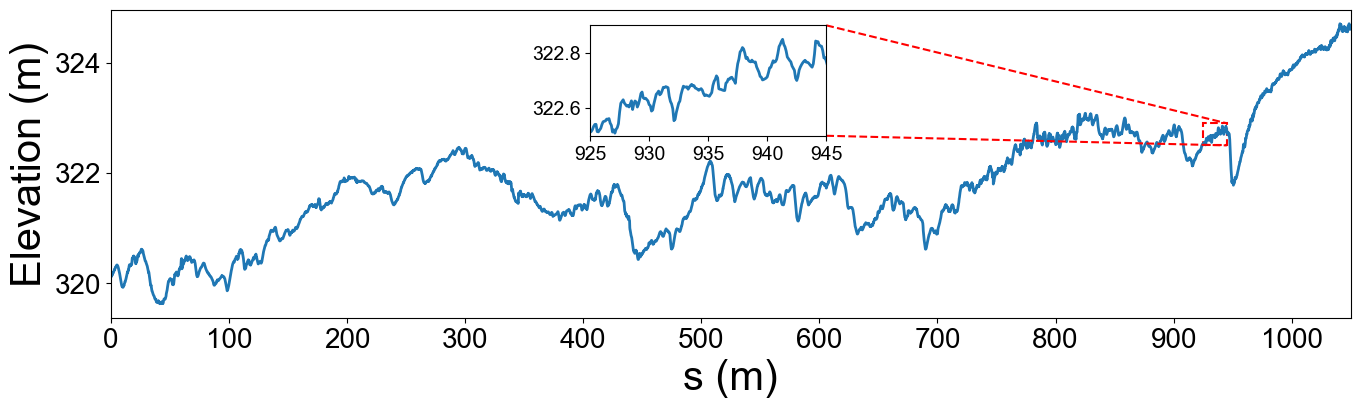

Profile PNG saved: outputs/mbs_longitudinal_profile.png


In [12]:
# ---------------- 绘制 z(s) 纵剖面 ----------------
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(16, 4))
m = np.isfinite(Z_mean)
ax.plot(S_s[m], Z_mean[m], '-', lw=2)
ax.set_xlim(0,1050)
ax.set_xlabel("s (m)", fontsize=30)
ax.set_ylabel("Elevation (m)", fontsize=30)
ax.set_xticks(np.arange(0,1100,100))

ax.tick_params(axis='both', labelsize=20)

x_left = 925    # 放大区域x轴左边界（对应s的最小值）
x_right = 945   # 放大区域x轴右边界（对应s的最大值）
y_bottom = 322.5  # 放大区域y轴下边界（对应高程最小值）
y_top = 322.9     # 放大区域y轴上边界（对应高程最大值）

# ---------------- 创建局部放大图（嵌入原图左上角，带完整坐标轴）----------------
# 1. 创建嵌入子图（inset_axes）：位于主图左上角，尺寸为宽30%、高30%
# bbox_to_anchor=(左, 下, 宽, 高)：基于主图坐标系（0-1范围），(0,0.7)对应左上角区域
ax_inset = inset_axes(
    ax,
    width="40%",
    height="40%",
    loc='upper left',
    # 锚点框四个值对应主图数据范围（left=x1, bottom=y1, width=x2-x1, height=y2-y1）
    bbox_to_anchor=(400, 319.8, 500, 5),  # 数据坐标系：左=100(s), 下=150(高程), 宽=200, 高=30
    bbox_transform=ax.transData  # 指定坐标系：数据坐标系
)

# 2. 在嵌入子图中绘制放大区域的数据（与主图数据一致，仅限制坐标轴范围）
ax_inset.plot(S_s[m], Z_mean[m], '-', lw=2)  # 放大图线条（不同颜色区分）

# 3. 设置放大图的坐标轴范围（核心：锁定到用户指定的上下左右）
ax_inset.set_xlim(x_left, x_right)
ax_inset.set_ylim(y_bottom, y_top)

# 4. 放大图坐标轴设置（带完整坐标轴，字体尺寸适配子图大小）
ax_inset.tick_params(axis='both', labelsize=14)  # 子图刻度字体适当缩小

# ---------------- （可选优化）标记主图中的放大区域（矩形框+连接线）----------------
# mark_inset：自动在主图绘制放大区域矩形框，并连接到嵌入子图
mark_inset(
    ax, ax_inset,
    loc1=1, loc2=4,  # 标记点位置（2=左上，4=右下，对应放大区域的两个角）
    fc="none",  # 矩形框填充色：透明
    ec="red",   # 矩形框边框色：红色
    lw=1.5,     # 边框线宽
    linestyle='--'  # 边框线型：虚线
)

# ---------------- 保存并显示图片（保留原始逻辑）----------------
fig.savefig(out_profile_png, dpi=300, bbox_inches='tight')  # bbox_inches='tight' 去除白边
plt.show()
plt.close(fig)
print(f"Profile PNG saved: {out_profile_png}")

In [13]:
# ===========================================
# Bed vs Surface (UAS image) — Joint Pipeline  [RECOMPUTE & CLIP CENTERLINE]
# 仅重算：centerline（重采样→按水面覆盖裁剪→两端各剪5%）与“水面走向”
# 不重算：沙波走向（读取先前结果），只做对比图 + 两张地图上的走向分布
# ===========================================

import os, json, math, csv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
import rasterio
from rasterio.transform import Affine

os.makedirs("outputs", exist_ok=True)

# ---------- 配置 ----------
ws_tif_path   = "MBS_data/TG20250726_straight1_UAV.tif"  # ← 水面 GeoTIFF
step_analyze_m = 2.0   # centerline 重采样间距
step_visual_m  = 5.0   # 地图上每 5 m 放一条小线段
# 水面走向窗口参数（与局部框一致）
Lt, Ln = 80.0, 80.0
nt, nn   = int(Lt/0.15), int(Ln/0.15)    # 窗内采样点数（沿/法向）
lam_min, lam_max = 1.0, 20.0
fmin, fmax = 1.0/lam_max, 1.0/lam_min
k_notch = 0.02
min_valid_frac = 0.40
qsharp_min     = 2.0
smooth_len_m   = 12.0

# ---------- 基础工具 ----------
def polyline_arclength(xs, ys):
    d = np.hypot(np.diff(xs), np.diff(ys))
    return np.concatenate([[0.0], np.cumsum(d)])

def resample_polyline(xs, ys, step):
    s = polyline_arclength(xs, ys)
    if s[-1] == 0: return xs.copy(), ys.copy(), s
    s_new = np.arange(0.0, s[-1] + 1e-9, step)
    return np.interp(s_new, s, xs), np.interp(s_new, s, ys), s_new

def tangent_normals(xs, ys):
    dx, dy = np.gradient(xs), np.gradient(ys)
    L = np.hypot(dx, dy) + 1e-12
    tx, ty = dx/L, dy/L
    nx, ny = -ty, tx
    return tx, ty, nx, ny

def raster_extent_from_transform(transform: Affine, shape):
    h, w = shape
    x0, y0 = (transform * (0, 0))
    x1, y1 = (transform * (w, 0))
    x2, y2 = (transform * (0, h))
    x3, y3 = (transform * (w, h))
    xs = [x0, x1, x2, x3]; ys = [y0, y1, y2, y3]
    return (min(xs), max(xs), min(ys), max(ys))

def inv_affine_xy_to_rc(transform, x, y):
    Ainv = ~transform
    c, r = Ainv * (x, y)
    return r, c

def sample_raster_nan(ras, transform, X, Y, order=1):
    r, c = inv_affine_xy_to_rc(transform, X, Y)
    return map_coordinates(ras, [r, c], order=order, mode="constant", cval=np.nan)

def hann2(nn, nt):
    return np.outer(np.hanning(nn), np.hanning(nt))

def circ_smooth_series(angles_deg, s_coords, win_len_m=12.0):
    if win_len_m <= 0 or len(angles_deg) < 3: return angles_deg.copy()
    out = angles_deg.copy(); half = 0.5*win_len_m
    for i, si in enumerate(s_coords):
        mask = (s_coords >= si-half) & (s_coords <= si+half) & np.isfinite(angles_deg)
        if mask.sum() >= 3:
            ang2 = np.radians(angles_deg[mask])*2.0
            C, S = np.cos(ang2).mean(), np.sin(ang2).mean()
            out[i] = (np.degrees(np.arctan2(S, C))/2.0) % 180.0
    return out

def fold_pm90(delta_deg):
    d = ((delta_deg + 90.0) % 180.0) - 90.0
    return np.clip(d, -90.0 + 1e-6, 90.0)

def detrend_plane(Z, X, Y):
    m = np.isfinite(Z)
    if m.sum() < 10: 
        return Z, 0.0
    x, y, z = X[m].ravel(), Y[m].ravel(), Z[m].ravel()
    A = np.c_[x, y, np.ones_like(x)]
    coeff, *_ = np.linalg.lstsq(A, z, rcond=None)
    Zfit = np.full_like(Z, np.nan, dtype=float)
    Zfit[m] = coeff[0]*X[m] + coeff[1]*Y[m] + coeff[2]
    return Z - Zfit, m.mean()

# ---------- 仅用于“水面走向”的 2D-DFT 方向估计 ----------
def orientation_along_track_surface(ras, transform, Xs, Ys, s_coords,
                                    Lt, Ln, nt, nn, fmin, fmax, k_notch,
                                    min_valid_frac=0.40, qsharp_min=2.0, smooth_len_m=12.0):
    tx, ty, nx, ny = tangent_normals(Xs, Ys)
    dt, dn = Lt/(nt-1), Ln/(nn-1)
    fx = np.fft.fftfreq(nt, d=dt); fy = np.fft.fftfreq(nn, d=dn)
    FX, FY = np.meshgrid(fx, fy, indexing="xy")
    FXs, FYs = np.fft.fftshift(FX), np.fft.fftshift(FY)
    R = np.hypot(FXs, FYs)
    band_mask  = (R >= fmin) & (R <= fmax)
    notch_mask = (np.abs(FXs) >= k_notch) & (np.abs(FYs) >= k_notch)
    base_mask  = band_mask & notch_mask

    nrings = 24
    bins = np.linspace(fmin, fmax, nrings+1)
    ring_idx = np.digitize(R, bins) - 1
    ring_counts = np.bincount(ring_idx[base_mask], minlength=nrings).astype(float)
    ring_counts[ring_counts==0] = np.inf
    ring_weight = np.zeros_like(R, dtype=float)
    for k in range(nrings):
        ring_weight[(ring_idx==k) & base_mask] = 1.0 / ring_counts[k]

    win2 = hann2(nn, nt)
    theta_k = np.full_like(s_coords, np.nan, float)
    quality = np.full_like(s_coords, np.nan, float)

    for i in range(len(s_coords)):
        T = np.linspace(-Lt/2, Lt/2, nt)
        N = np.linspace(-Ln/2, Ln/2, nn)
        TT, NN = np.meshgrid(T, N, indexing="xy")
        Xloc = Xs[i] + TT*tx[i] + NN*nx[i]
        Yloc = Ys[i] + TT*ty[i] + NN*ny[i]
        Zloc = sample_raster_nan(ras, transform, Xloc, Yloc)
        vf = np.isfinite(Zloc).mean()
        if not np.isfinite(vf) or vf < min_valid_frac:
            continue
        Zd, _ = detrend_plane(Zloc, Xloc, Yloc)
        m = np.isfinite(Zd)
        if m.sum() < 10: 
            continue
        mu = float(np.nanmean(Zd[m]))
        Zw = (np.where(m, Zd - mu, 0.0)) * win2

        F  = np.fft.fft2(Zw)
        P  = np.fft.fftshift(np.abs(F)**2)
        Wt = P * ring_weight

        Mxx = np.sum(Wt * (FXs**2))
        Mxy = np.sum(Wt * (FXs*FYs))
        Myy = np.sum(Wt * (FYs**2))
        evals, evecs = np.linalg.eigh(np.array([[Mxx, Mxy],[Mxy, Myy]], float))
        if not np.all(np.isfinite(evals)): 
            continue
        imax = int(np.argmax(evals))
        vx, vy = float(evecs[0, imax]), float(evecs[1, imax])
        theta_k[i] = (np.degrees(np.arctan2(vy, vx)) % 180.0)

        lmin = max(evals.min(), 1e-12)
        lmax = max(evals.max(), lmin)
        quality[i] = lmax / lmin

    ok = (quality >= qsharp_min) & np.isfinite(theta_k)
    if ok.any():
        bad_idx = np.where(~ok)[0]
        for i in bad_idx:
            j = np.argmin(np.abs(s_coords[ok] - s_coords[i]))
            if np.abs(s_coords[ok][j] - s_coords[i]) <= 2.0*Lt:
                theta_k[i] = theta_k[ok][j]
                quality[i] = quality[ok][j]

    theta_abs_sm = circ_smooth_series(theta_k, s_coords, smooth_len_m)
    return theta_k, theta_abs_sm, quality

# ---------- 角度插值（0..180°）到新 s 网（双角插值） ----------
def interp_angle_0_180(S_src, ang_src_deg, S_new):
    ang_src = np.asarray(ang_src_deg, float) % 180.0
    c2 = np.cos(np.deg2rad(2.0*ang_src))
    s2 = np.sin(np.deg2rad(2.0*ang_src))
    c2_i = np.interp(S_new, S_src, c2)
    s2_i = np.interp(S_new, S_src, s2)
    ang2 = np.degrees(np.arctan2(s2_i, c2_i))
    ang  = (ang2/2.0) % 180.0
    return ang

# ---------- 读取水面 GeoTIFF ----------
with rasterio.open(ws_tif_path) as ds:
    ws_crs       = ds.crs
    ws_transform = ds.transform
    ws_nodata    = ds.nodata
    arr = ds.read()
    if arr.ndim == 3 and arr.shape[0] >= 3:
        R, G, B = arr[0].astype(float), arr[1].astype(float), arr[2].astype(float)
        I = 0.299*R + 0.587*G + 0.114*B
    else:
        I = arr[0].astype(float)
    if ws_nodata is not None:
        I = np.where(I == ws_nodata, np.nan, I)
    Imin = np.nanpercentile(I, 2) if np.isfinite(I).sum()>1000 else np.nanmin(I)
    Imax = np.nanpercentile(I,98) if np.isfinite(I).sum()>1000 else np.nanmax(I)
    ws_data = (I - Imin) / (Imax - Imin + 1e-12)
    ws_extent_full = raster_extent_from_transform(ws_transform, ws_data.shape)

# 水面有效紧边界（去 nodata）
ws_fin = np.isfinite(ws_data)
if np.any(ws_fin):
    rows = np.where(ws_fin.any(axis=1))[0]
    cols = np.where(ws_fin.any(axis=0))[0]
    r0, r1 = int(rows.min()), int(rows.max())
    c0, c1 = int(cols.min()), int(cols.max())
    x0, y0 = (ws_transform * (c0, r0))
    x1, y1 = (ws_transform * (c1, r0))
    x2, y2 = (ws_transform * (c0, r1))
    x3, y3 = (ws_transform * (c1, r1))
    ws_extent_valid = (min(x0,x1,x2,x3), max(x0,x1,x2,x3), min(y0,y1,y2,y3), max(y0,y1,y2,y3))
else:
    ws_extent_valid = ws_extent_full

# ---------- 重新计算 centerline → 裁剪 → 两端各剪 5% ----------
if 'Xs_s' in globals() and 'Ys_s' in globals():
    X0, Y0 = np.asarray(Xs_s, float), np.asarray(Ys_s, float)
elif 'X_an' in globals() and 'Y_an' in globals():
    X0, Y0 = np.asarray(X_an, float), np.asarray(Y_an, float)
else:
    raise RuntimeError("未找到原始 centerline（缺少 Xs_s/Ys_s 或 X_an/Y_an）。")

X_rs, Y_rs, S_rs = resample_polyline(X0, Y0, step_analyze_m)
vals = sample_raster_nan(ws_data, ws_transform, X_rs, Y_rs)
ok = np.isfinite(vals)

def longest_true_run(mask):
    best_len, best_range = 0, (None, None); start=None
    for i,v in enumerate(mask):
        if v and start is None: start=i
        if (not v or i==len(mask)-1) and start is not None:
            end = i if not v else i+1
            if (end-start) > best_len: best_len, best_range = (end-start),(start,end)
            start=None
    return best_len, best_range

run_len, (i0, i1) = longest_true_run(ok)
if run_len < max(10, int(20.0/step_analyze_m)):
    raise RuntimeError("水面覆盖与中心线重叠过少，无法稳健裁剪。")

trim = int(round(0.05 * run_len))
i0_clip = i0 + trim
i1_clip = i1 - trim
if i1_clip - i0_clip < max(10, int(20.0/step_analyze_m)):
    i0_clip, i1_clip = i0, i1

X_an = X_rs[i0_clip:i1_clip].copy()
Y_an = Y_rs[i0_clip:i1_clip].copy()
S_an = polyline_arclength(X_an, Y_an)

print(f"[info] centerline clipped: points={len(S_an)}, S=[{S_an[0]:.2f}, {S_an[-1]:.2f}] m")

# ---------- 新计算：水面走向（仅此项重算） ----------
theta_ws_abs, theta_ws_abs_sm, Q_ws = orientation_along_track_surface(
    ws_data, ws_transform, X_an, Y_an, S_an,
    Lt, Ln, nt, nn, fmin, fmax, k_notch,
    min_valid_frac=min_valid_frac, qsharp_min=qsharp_min, smooth_len_m=smooth_len_m
)

# ---------- 读取“先前已计算”的沙波走向并插值到新 S_an ----------
S_bed_src, theta_bed_raw_src, theta_bed_sm_src = None, None, None
geojson_path = "outputs/mbs_flowdir_centerline_epsg32649.geojson"

if os.path.exists(geojson_path):
    try:
        with open(geojson_path, "r", encoding="utf-8") as f:
            gj = json.load(f)
        props = gj["features"][0]["properties"]
        S_bed_src = np.asarray(props.get("s_m", []), float)
        
        # 读取原始数据（如果存在），否则读取平滑数据
        if "theta_flow_deg_raw" in props:
            theta_bed_raw_src = np.asarray(props.get("theta_flow_deg_raw", []), float)
            theta_bed_sm_src = np.asarray(props.get("theta_flow_deg_sm", []), float)
            print(f"[info] loaded bed orientation (raw & smoothed) from GeoJSON: {geojson_path}")
        else:
            # 向后兼容：如果只有平滑数据
            print("[info] GeoJSON只包含平滑数据，使用平滑数据作为原始数据")
            theta_bed_sm_src = np.asarray(props.get("theta_flow_deg", []), float)
            theta_bed_raw_src = theta_bed_sm_src.copy()  # 用平滑数据作为原始数据
            print(f"[info] loaded bed orientation (smoothed only) from GeoJSON: {geojson_path}")
    except Exception as e:
        print("[warn] fail to read GeoJSON:", e)
        S_bed_src, theta_bed_raw_src, theta_bed_sm_src = None, None, None

if (S_bed_src is None or theta_bed_raw_src is None) and ("theta_flow_sm" in globals() and "S_an_bedref" in globals()):
    print("[info] using in-memory theta_flow_sm with S_an_bedref")
    S_bed_src = np.asarray(S_an_bedref, float)
    theta_bed_sm_src = np.asarray(theta_flow_sm, float)
    theta_bed_raw_src = theta_bed_sm_src.copy()  # 用平滑数据作为原始数据

if S_bed_src is None or theta_bed_raw_src is None or theta_bed_sm_src is None:
    raise RuntimeError("未能获取先前的沙波走向（建议先运行沙波走向模块并输出 GeoJSON）。")

theta_bed_abs_raw = interp_angle_0_180(S_bed_src, theta_bed_raw_src, S_an)
theta_bed_abs_sm = interp_angle_0_180(S_bed_src, theta_bed_sm_src, S_an)

# ---------- θ(s) 对比图（±90°，相对切向） ----------
tx, ty, _, _ = tangent_normals(X_an, Y_an)
phi_t = (np.degrees(np.arctan2(ty, tx)) % 180.0)
theta_ws_pm90_raw = fold_pm90(theta_ws_abs - phi_t)
theta_ws_pm90_sm  = fold_pm90(theta_ws_abs_sm - phi_t)
theta_bed_pm90_raw = fold_pm90(theta_bed_abs_raw - phi_t)
theta_bed_pm90_sm = fold_pm90(theta_bed_abs_sm - phi_t)

xticks = np.arange(math.ceil(S_an[0]/100)*100, S_an[-1]+1e-9, 100.0)



[info] centerline clipped: points=477, S=[0.00, 911.10] m
[info] loaded bed orientation (raw & smoothed) from GeoJSON: outputs/mbs_flowdir_centerline_epsg32649.geojson


In [14]:
print(max(np.abs(theta_bed_pm90_sm-theta_ws_pm90_sm)))
print(np.sqrt(np.mean(np.square(theta_bed_pm90_sm-theta_ws_pm90_sm))))
print(np.mean(np.abs(theta_bed_pm90_sm-theta_ws_pm90_sm)))

25.153965407177324
10.491512056407482
8.889770594090427


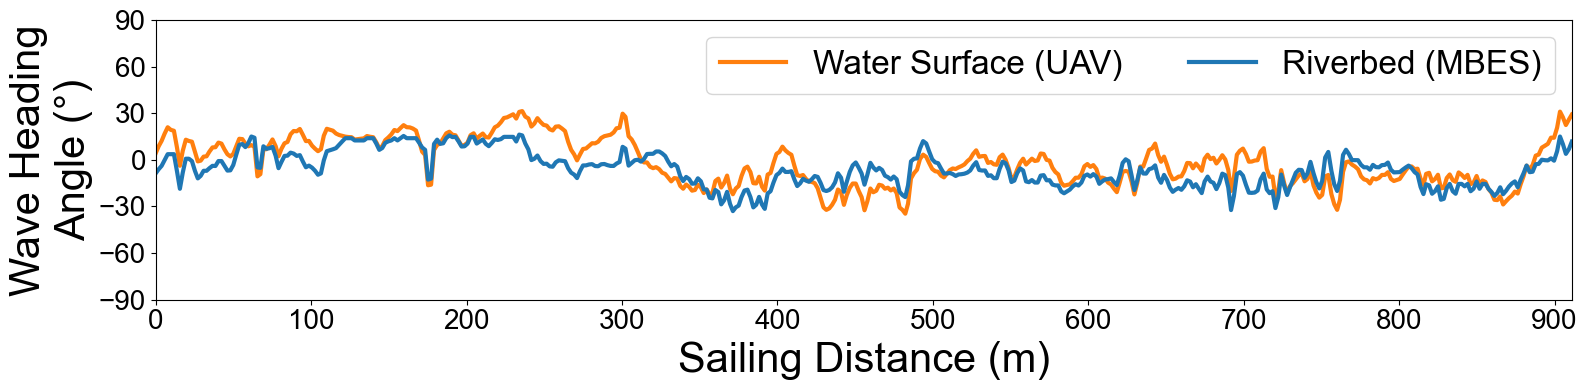

saved: outputs/compare_theta_bed_vs_surface_RECLIP.png


In [15]:

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(S_an, theta_ws_pm90_sm,  '-', lw=3, color='tab:orange', alpha=1, label='Water Surface (UAV)')
ax.plot(S_an, theta_bed_pm90_sm,  '-', lw=3, color='tab:blue',   alpha=1, label='Riverbed (MBES)')

valid_ws_raw = np.isfinite(theta_ws_pm90_raw)
valid_bed_raw = np.isfinite(theta_bed_pm90_raw)

#ax.scatter(S_an[valid_ws_raw], theta_ws_pm90_raw[valid_ws_raw], s=15, color='tab:orange', alpha=1, label='Water Surface (raw)', edgecolor='none', zorder=5, marker='o')
#ax.scatter(S_an[valid_bed_raw], theta_bed_pm90_raw[valid_bed_raw], s=15, color='tab:blue', alpha=1, label='Riverbed (raw)', edgecolor='none', zorder=5, marker='o')

ax.set_xlim(S_an[0], S_an[-1])
ax.set_xticks(xticks)
ax.set_yticks(np.arange(-90, 91, 30))
ax.tick_params(axis='both', labelsize=20)  # 添加这行，设置x轴刻度字体大小
ax.set_ylim(-90, 90)
#ax.axhline(0.0, color='gray', lw=1.0, ls='--', alpha=0.7, label='Heading')
ax.set_xlabel("Sailing Distance (m)", fontsize=30)
ax.set_ylabel("Wave Heading\nAngle (°)", fontsize=30)
ax.legend(loc='upper right', frameon=True, ncol=3, fontsize=24)
fig.tight_layout()
out_theta_png = "outputs/compare_theta_bed_vs_surface_RECLIP.png"
fig.savefig(out_theta_png, dpi=300)
plt.show()
plt.close(fig)
print("saved:", out_theta_png)